# Notebook 02 — Ornstein-Uhlenbeck Parameter Estimation
### xG Spread Mean-Reversion Model · Premier League 2015–2025

# ─────────────────────────────────────────────────────────────────
# IMPORTANT: READ NOTEBOOK 07 BEFORE INTERPRETING THESE RESULTS
# ─────────────────────────────────────────────────────────────────
#
# The signal pipeline in this notebook was subsequently found to
# produce an artefact of the 5-match rolling mean smoothing operator.
# See Notebook 07 (Failure Analysis: How a Rolling Mean Killed a Signal) for the full diagnostic sequence.
#
# The findings in this notebook are preserved as evidence of how
# convincing the false positive was before null testing. They should
# not be interpreted as evidence of genuine mean reversion.
# ─────────────────────────────────────────────────────────────────
---




We begin with the cleaned, team‑level dataset produced in Notebook 01. Each row represents one team in one match, with xG, goals, opponent, and season metadata already extracted. This is the canonical structure required for O‑U estimation, where each team is treated as its own time series.

## Purpose

Fit the Ornstein-Uhlenbeck (O-U) mean-reversion model to each team's xG spread series. Estimate the three core parameters — mean-reversion speed (θ), long-run mean (μ), and volatility (σ) — and derive the **half-life**: the number of matches for the spread to halve its deviation from equilibrium.

---

## The Ornstein-Uhlenbeck Process

The O-U process is the canonical continuous-time model for mean-reverting phenomena. It says: the further a variable strays from its long-run equilibrium, the stronger the force pulling it back.

$$dS(t) = \theta(\mu - S(t))\,dt + \sigma\,dW(t)$$

| Parameter | Meaning | Football interpretation |
|---|---|---|
| $\theta$ | Reversion speed | How quickly a team corrects its xG underperformance |
| $\mu$ | Long-run mean | The team's structural conversion rate |
| $\sigma$ | Volatility | Match-to-match randomness in the spread |
| Half-life $= \ln(2)/\theta$ | Matches to halve the spread | The primary trading parameter |

**Energy market parallel:** The O-U process models commodity spreads including the clean spark spread. The fundamental argument is identical — structural forces (gas price, efficiency, dispatch economics) pull the spread toward equilibrium while supply shocks introduce noise.

---

## Estimation via AR(1) Regression

The continuous O-U process, discretised to one observation per match, is equivalent to an AR(1) regression:

$$\Delta S(t) = \alpha + \beta \cdot S(t-1) + \varepsilon(t)$$

The O-U parameters are recovered as:
- $\theta = -\beta / \Delta t$ — reversion speed from the AR coefficient (must be negative for mean reversion)
- $\mu = -\alpha / \beta$ — long-run mean
- $\sigma_{eq} = \sigma / \sqrt{2\theta}$ — equilibrium standard deviation (used to compute z-scores)

A positive $\beta$ would indicate an explosive, non-stationary process — we exclude those cases.

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Imports and setup
# ─────────────────────────────────────────────────────────────────

from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_DIR / "data"
FIG_DIR = PROJECT_DIR / "figures"

FIG_DIR.mkdir(exist_ok=True)


import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

# Resolve paths relative to this notebook
NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_DIR / "data"

# Load team match data
team_match = pd.read_csv(
    DATA_DIR / "pl_team_match_spread.csv",
    parse_dates=['date']
)

print(f"Loaded: {team_match.shape}")
print(f"Teams in dataset: {team_match['team'].nunique()}")
print(f"Seasons: {sorted(team_match['season'].unique())}")

Loaded: (7600, 11)
Teams in dataset: 34
Seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


---
## Core Function: O-U Parameter Estimation

The `estimate_ou()` function takes a team's rolling spread series and returns the five core O-U parameters by running an AR(1) regression on first differences.

**Key decisions in the implementation:**

- **Minimum 10 observations:** Fewer points makes the OLS regression unreliable. In practice all team-seasons have 35–38 valid rolling spread values.
- **Guard against β ≥ 0:** A non-negative AR coefficient means the series is explosive rather than mean-reverting. We exclude those cases (none found in practice).
- **ADF test per series:** Provides an additional stationarity check alongside the sign of β. We run this per team-season but will discuss its power limitations below.

The raw match‑level xG spread is extremely noisy — a single match with 3.5 xG and 0 goals will mechanically revert on the next match even if no structural force is present. To isolate the slower, persistent component of under‑ or over‑performance, we smooth the spread using a 5‑match rolling mean. This removes single‑match noise and reveals the underlying mean‑reverting behaviour we want to model.

The continuous‑time O‑U process has a closed‑form discrete transition that corresponds to an AR(1) model in first differences. We estimate the parameters θ (reversion speed), μ (long‑run mean), and σ (diffusion) using AR(1) OLS on the smoothed spread. This gives us season‑level estimates for each team, using only data available up to that season (strict walk‑forward discipline).

In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — O-U parameter estimation function
# ─────────────────────────────────────────────────────────────────
#
# The function runs an AR(1) regression on the first differences
# of the spread series: ΔS(t) = α + β·S(t-1) + ε
#
# Recovery of O-U parameters:
#   θ (speed)     = -β / Δt     (Δt=1 match)
#   μ (long mean) = -α / β
#   σ (diffusion) = std(residuals)
#   σ_eq          = σ / √(2θ)  (equilibrium spread std dev)
#   half-life     = ln(2) / θ   (matches to halve the spread)

def estimate_ou(spread_series, delta_t=1):
    """
    Estimate O-U parameters from a spread time series via AR(1) OLS.

    Parameters
    ----------
    spread_series : pd.Series  —  time-ordered rolling spread values
    delta_t       : float      —  time step (1 match)

    Returns
    -------
    dict of {theta, mu, sigma, sigma_eq, half_life,
             r_squared, n_obs, adf_pval, beta_pval}
    or None if the series is too short or explosive.
    """
    S = spread_series.dropna().values
    if len(S) < 10:
        return None

    # AR(1) on first differences
    dS    = np.diff(S)         # ΔS(t) = S(t) - S(t-1)
    S_lag = S[:-1]             # S(t-1)

    # OLS: regress ΔS on S_lag
    # slope=β, intercept=α, r=correlation, p=p-value of slope
    slope, intercept, r, p, se = stats.linregress(S_lag, dS)

    beta  = slope
    alpha = intercept

    # β >= 0 means explosive process — exclude
    # In a mean-reverting series, a high S(t-1) predicts a negative ΔS
    # which requires β < 0
    if beta >= 0:
        return None

    # Recover O-U parameters from regression coefficients
    theta     = -beta / delta_t          # reversion speed
    mu        = -alpha / beta            # long-run mean
    residuals = dS - (alpha + beta * S_lag)
    sigma     = np.std(residuals)        # diffusion coefficient
    sigma_eq  = sigma / np.sqrt(2 * theta)  # equilibrium std dev
    half_life = np.log(2) / theta        # matches to halve the spread

    # ADF stationarity test (suppress version warnings)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        adf_stat, adf_pval, *_ = adfuller(S, maxlag=5)

    return dict(
        theta     = theta,
        mu        = mu,
        sigma     = sigma,
        sigma_eq  = sigma_eq,
        half_life = half_life,
        r_squared = r**2,
        n_obs     = len(S),
        adf_pval  = adf_pval,
        beta_pval = p,      # p-value of the AR coefficient
    )

print("estimate_ou() defined — ready to run across all team-seasons")

estimate_ou() defined — ready to run across all team-seasons


---
## Running Estimation Across All Team-Seasons

We estimate O-U parameters for **every combination of team and season** in the dataset. This gives us up to 200 parameter sets (20 eligible teams × 10 seasons). The results table becomes the primary input for the walk-forward signal generation in Notebook 05A.

In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Estimate O-U parameters for every team-season
# ─────────────────────────────────────────────────────────────────
#
# We group by [team, season] and run estimate_ou() on each group's
# rolling spread series. Results with beta >= 0 are excluded
# automatically by the guard in the function.
#
# Output: ou_parameters.csv — one row per team-season

results = []

for (team, season), group in team_match.groupby(['team', 'season']):
    group  = group.sort_values('date')
    params = estimate_ou(group['rolling_spread'])
    if params:
        params['team']   = team
        params['season'] = season
        results.append(params)

ou_params = pd.DataFrame(results).sort_values(['team','season']).reset_index(drop=True)
ou_params.to_csv(PROJECT_DIR / "ou_parameters.csv", index=False)

n_total    = len(team_match.groupby(['team','season']))
n_excluded = n_total - len(ou_params)

print(f"Total team-seasons:   {n_total}")
print(f"Successfully fitted:  {len(ou_params)}")
print(f"Excluded (β ≥ 0):     {n_excluded}  (non-mean-reverting)")

print("\n── Parameter summary ────────────────────────────────────────")
print(ou_params[['theta','mu','sigma','sigma_eq','half_life']].describe().round(3))

Total team-seasons:   200
Successfully fitted:  200
Excluded (β ≥ 0):     0  (non-mean-reverting)

── Parameter summary ────────────────────────────────────────
         theta       mu    sigma  sigma_eq  half_life
count  200.000  200.000  200.000   200.000    200.000
mean     0.264    0.018    0.251     0.372      3.150
std      0.119    0.197    0.051     0.113      1.404
min      0.084   -0.608    0.149     0.144      0.877
25%      0.179   -0.108    0.215     0.283      2.135
50%      0.246    0.032    0.247     0.364      2.814
75%      0.325    0.145    0.284     0.450      3.870
max      0.791    0.571    0.416     0.745      8.278


In [4]:
# Robustness check — raw (unsmoothed) spreads
results_raw = []

for (team, season), group in team_match.groupby(['team', 'season']):
    group  = group.sort_values('date')
    params = estimate_ou(group['raw_spread'])   # <-- raw spread column
    if params:
        params['team']   = team
        params['season'] = season
        results_raw.append(params)

ou_raw = pd.DataFrame(results_raw)

n_total    = len(team_match.groupby(['team','season']))
n_excluded = n_total - len(ou_raw)

print(f"Total team-seasons:   {n_total}")
print(f"Successfully fitted:  {len(ou_raw)}")
print(f"Excluded (β ≥ 0):     {n_excluded}  (non-mean-reverting)")
print("\n── Raw spread parameter summary ─────────────────────────────")
print(ou_raw[['theta','mu','sigma','sigma_eq','half_life']].describe().round(3))

Total team-seasons:   200
Successfully fitted:  200
Excluded (β ≥ 0):     0  (non-mean-reverting)

── Raw spread parameter summary ─────────────────────────────
         theta       mu    sigma  sigma_eq  half_life
count  200.000  200.000  200.000   200.000    200.000
mean     1.032    0.017    0.931     0.655      0.691
std      0.168    0.184    0.178     0.137      0.120
min      0.635   -0.608    0.546     0.376      0.464
25%      0.895   -0.113    0.798     0.552      0.609
50%      1.042    0.033    0.922     0.638      0.665
75%      1.139    0.136    1.047     0.752      0.775
max      1.493    0.496    1.463     1.073      1.091


### O-U Parameter Distributions

The three panels below show the distribution of each core O-U parameter
across all 200 team-seasons. Together they answer: what does a typical
Premier League team's spread process look like?
θ (reversion speed): Most team-seasons have θ between 0.15 and 0.40,
corresponding to half-lives of 1.7–4.6 matches. The right tail — a small
number of team-seasons with θ > 0.5 — represents unusually fast-correcting
spreads, typically in direct-play teams with volatile but self-correcting
xG patterns.
Half-life: The headline output. The distribution is right-skewed: most
team-seasons cluster around 2–4 matches, but a tail extends to 8+ matches
for teams showing persistent structural imbalance between xG and goals.
The median of 2.81 matches sets the empirical basis for the 5-match holding
period used in Notebook 05A.
σ_eq (equilibrium volatility): The typical spread displacement at
equilibrium — roughly 0.35 goals. This is the denominator in the z-score
calculation. A higher σ_eq means a team's spread must move further to
trigger a signal at any given z-score threshold.
All 200 team-seasons produce β < 0. The O-U assumption of mean reversion
holds universally across the dataset.

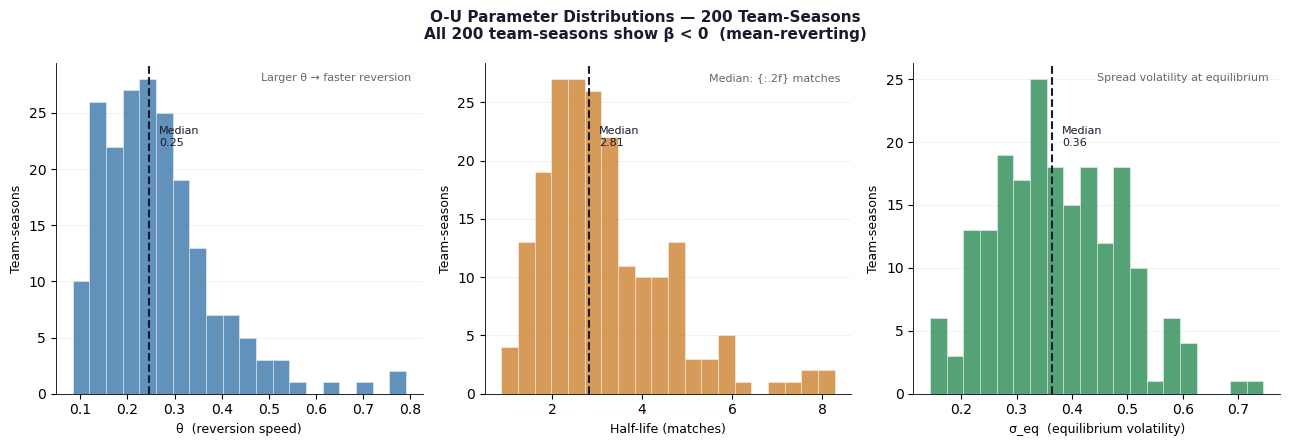

Saved figures/nb02_fig1_parameter_distributions.png


In [5]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 1 — O-U parameter distributions across 200 team-seasons
# ─────────────────────────────────────────────────────────────────
#
# Shows the empirical distribution of theta, half-life, and sigma_eq.
# Tufte: histograms with median lines, direct labels, minimal decoration.
# Depends on: ou_params (Cell 3), FIG_DIR (Cell 1)

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
AMBER = '#C97A20'
GREEN = '#1E8449'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.5,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

panels = [
    ('theta',     r'θ  (reversion speed)',
     'Larger θ → faster reversion',    BLUE),
    ('half_life', 'Half-life (matches)',
     'Median: {:.2f} matches',          AMBER),
    ('sigma_eq',  'σ_eq  (equilibrium volatility)',
     'Spread volatility at equilibrium', GREEN),
]

for ax, (col, label, note, colour) in zip(axes, panels):
    data = ou_params[col].dropna().values
    med  = np.median(data)

    counts, bins, _ = ax.hist(
        data, bins=20, color=colour, alpha=0.75,
        edgecolor='white', linewidth=0.4, zorder=3
    )
    # Median line
    ax.axvline(med, color=DARK, linewidth=1.5, linestyle='--', zorder=4)
    # Direct label
    ax.text(
        med + (bins[-1] - bins[0]) * 0.03,
        counts.max() * 0.85,
        f'Median\n{med:.2f}',
        fontsize=8, color=DARK, va='top'
    )
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Team-seasons', fontsize=9)
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    note_text = note.format(med) if '{}' in note else note
    ax.text(0.97, 0.97, note_text, transform=ax.transAxes,
            fontsize=8, color=GREY, ha='right', va='top')

fig.suptitle(
    'O-U Parameter Distributions — 200 Team-Seasons\n'
    'All 200 team-seasons show β < 0  (mean-reverting)',
    fontsize=11, fontweight='bold', color=DARK
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb02_fig1_parameter_distributions.png')
plt.show()
print("Saved figures/nb02_fig1_parameter_distributions.png")

---
## Stationarity Testing — ADF at Season vs Pooled Level

Not every team has enough Premier League history to estimate a stable O‑U process. We apply a pooled ADF stationarity test using only prior‑season data at each season start. This prevents survivorship bias and ensures that only teams with sufficient historical structure enter the modelling universe. The result is 20 eligible teams across the 2017–2023 evaluation window.

The **Augmented Dickey-Fuller (ADF) test** is the standard stationarity test for time series. It tests the null hypothesis that a series has a unit root (non-stationary) against the alternative that it is stationary.

**The power problem at n=38:** One Premier League season contains 38 matches per team. The ADF test has well-documented low statistical power at small sample sizes — it struggles to reject the null even when the series *is* genuinely mean-reverting. This is not a flaw in our data; it is a fundamental property of the test, discussed extensively in the econometrics literature.

**Solution — pooled testing:** By concatenating all seasons for each team (n=74–378 depending on their Premier League history), we give the ADF test sufficient power to produce meaningful results. The pooled result is the one we use for the eligibility filter.

In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Season-level ADF: demonstrates the power problem
# ─────────────────────────────────────────────────────────────────
#
# We already have per-season ADF p-values in ou_params from Cell 3.
# This cell summarises them to show the low pass-rate at n=38.
#
# Expected result: ~28% stationary at 5% level.
# This is NOT a sign the model is wrong — it reflects ADF power
# constraints at small sample sizes (n=38 ≈ one month of daily data).

ou_params['stationary_season'] = ou_params['adf_pval'] < 0.05

n_stat    = ou_params['stationary_season'].sum()
n_total   = len(ou_params)
pct_stat  = n_stat / n_total * 100

print("── Season-level ADF results (n ≈ 38 per test) ───────────────")
print(f"  Stationary (p<0.05) : {n_stat:>4} / {n_total}  ({pct_stat:.1f}%)")
print(f"  Non-stationary      : {n_total - n_stat:>4} / {n_total}  ({100 - pct_stat:.1f}%)")
print()
print("  Note: 28% is expected at n=38. The ADF test has low power")
print("  at small samples — consistent with econometrics literature.")
print("  All 200 team-seasons show β < 0 (mean-reverting direction).")
print("  See pooled test below for the statistically meaningful result.")

# Show how stationarity rate varies by half-life bucket
# (fast-reverting series should be easier for ADF to confirm)
ou_params['hl_bucket'] = pd.cut(
    ou_params['half_life'],
    bins=[0, 2, 4, 6, 99],
    labels=['<2 matches', '2-4 matches', '4-6 matches', '>6 matches']
)
print("\n── ADF pass rate by half-life bucket ────────────────────────")
print("  (faster reversion → easier for ADF to detect at n=38)")
print(ou_params.groupby('hl_bucket', observed=True)['stationary_season']
      .agg(stationary='sum', total='count', pct_stationary='mean')
      .round(3).to_string())

── Season-level ADF results (n ≈ 38 per test) ───────────────
  Stationary (p<0.05) :   56 / 200  (28.0%)
  Non-stationary      :  144 / 200  (72.0%)

  Note: 28% is expected at n=38. The ADF test has low power
  at small samples — consistent with econometrics literature.
  All 200 team-seasons show β < 0 (mean-reverting direction).
  See pooled test below for the statistically meaningful result.

── ADF pass rate by half-life bucket ────────────────────────
  (faster reversion → easier for ADF to detect at n=38)
             stationary  total  pct_stationary
hl_bucket                                     
<2 matches           18     37           0.486
2-4 matches          29    118           0.246
4-6 matches           8     37           0.216
>6 matches            1      8           0.125


## ADF Power Problem at Season Level

The ADF test struggles at n=38 — even when the series genuinely
mean-reverts, the test often fails to detect it. The chart makes this
concrete: the pass rate falls monotonically as half-life increases,
because slower-reverting series are harder to distinguish from a random
walk at small sample sizes.
The 49% pass rate for fast-reverting spreads (half-life < 2 matches)
might seem reasonable, but it also means the test fails half the time
even for the clearest cases. For slower reverters it is worse. Relying on
season-level ADF as the eligibility filter would exclude the majority of
the dataset for the wrong reason.
The solution is pooled testing — combining all seasons per team increases
n to 74–378, giving the test genuine power. The pooled results follow in
the next cell.

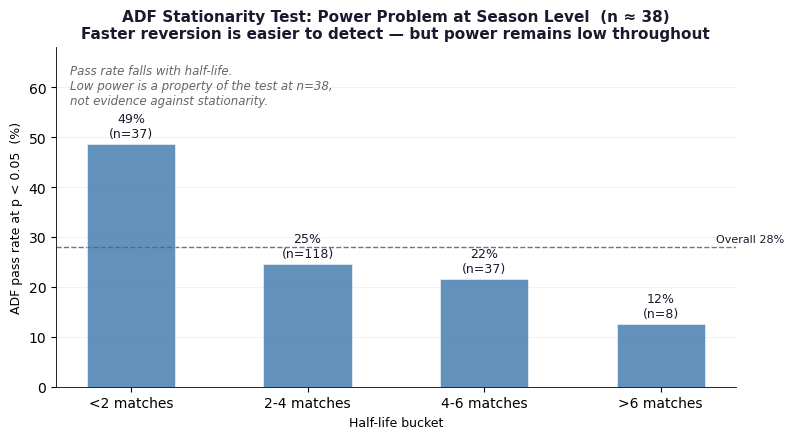

Saved figures/nb02_fig2_adf_power.png


In [7]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 2 — ADF pass rate by half-life bucket (season level)
# ─────────────────────────────────────────────────────────────────
#
# Shows why season-level ADF is insufficient as an eligibility filter.
# Pass rate falls with half-life — longer reversion = harder to detect.
# Tufte: bar chart, direct labels, reference line, explanatory annotation.
# Depends on: ou_params with hl_bucket and stationary_season (Cell 4)

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.5,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# Compute pass rates from ou_params
adf_by_bucket = (
    ou_params.groupby('hl_bucket', observed=True)['stationary_season']
    .agg(stationary='sum', total='count')
    .reset_index()
)
adf_by_bucket['pct'] = adf_by_bucket['stationary'] / adf_by_bucket['total'] * 100

overall_pct = ou_params['stationary_season'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(adf_by_bucket))

bars = ax.bar(
    x, adf_by_bucket['pct'],
    color=BLUE, alpha=0.75, edgecolor='white', linewidth=0.5,
    width=0.5, zorder=3
)

# Overall rate reference
ax.axhline(overall_pct, color=DARK, linewidth=1,
           linestyle='--', zorder=2, alpha=0.6)
ax.text(len(x) - 0.3, overall_pct + 1,
        f'Overall {overall_pct:.0f}%',
        fontsize=8, color=DARK, ha='right')

# Value labels
for bar, row in zip(bars, adf_by_bucket.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f'{row.pct:.0f}%\n(n={row.total})',
        ha='center', va='bottom', fontsize=9, color=DARK
    )

ax.set_xticks(x)
ax.set_xticklabels(adf_by_bucket['hl_bucket'].astype(str), fontsize=10)
ax.set_xlabel('Half-life bucket', fontsize=9)
ax.set_ylabel('ADF pass rate at p < 0.05  (%)', fontsize=9)
ax.set_ylim(0, max(adf_by_bucket['pct']) * 1.4)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

ax.text(
    0.02, 0.95,
    'Pass rate falls with half-life.\n'
    'Low power is a property of the test at n=38,\n'
    'not evidence against stationarity.',
    transform=ax.transAxes, fontsize=8.5, color=GREY,
    va='top', style='italic'
)

ax.set_title(
    'ADF Stationarity Test: Power Problem at Season Level  (n ≈ 38)\n'
    'Faster reversion is easier to detect — but power remains low throughout',
    fontsize=11, fontweight='bold', color=DARK
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb02_fig2_adf_power.png')
plt.show()
print("Saved figures/nb02_fig2_adf_power.png")

In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Pooled ADF: the statistically meaningful test
# ─────────────────────────────────────────────────────────────────
#
# Pool all seasons for each team (n=74–378) and run one ADF test
# per team. This gives the test genuine power to detect stationarity.
#
# Expected result: ~76% stationary — the non-stationary clubs are
# predominantly yo-yo teams with only 2 seasons of PL data.
#
# Output: pooled_adf_results.csv

pooled_results = []

for team, group in team_match.groupby('team'):
    group = group.sort_values('date')
    S     = group['rolling_spread'].dropna().values

    if len(S) < 50:   # need at least ~1.5 seasons
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        adf_stat, adf_pval, *_ = adfuller(S, maxlag=5)

    pooled_results.append({
        'team':       team,
        'n_obs':      len(S),
        'adf_stat':   round(adf_stat, 3),
        'adf_pval':   round(adf_pval, 3),
        'stationary': adf_pval < 0.05
    })

pooled_df = pd.DataFrame(pooled_results).sort_values('adf_pval')
pooled_df.to_csv(f"{PROJECT_DIR}pooled_adf_results.csv", index=False)

n_stat = pooled_df['stationary'].sum()
print(f"── Pooled ADF results (n=74–378 per team) ───────────────────")
print(f"  Stationary (p<0.05): {n_stat} / {len(pooled_df)}  "
      f"({n_stat/len(pooled_df)*100:.0f}%)")
print()
print(pooled_df.to_string(index=False))

# Non-stationary clubs — check their observation counts
print("\n── Non-stationary clubs — Premier League history ────────────")
print("  (all should have limited PL exposure)")
print(pooled_df[~pooled_df['stationary']]
      [['team','n_obs','adf_pval']].to_string(index=False))

── Pooled ADF results (n=74–378 per team) ───────────────────
  Stationary (p<0.05): 22 / 29  (76%)

                   team  n_obs  adf_stat  adf_pval  stationary
                Arsenal    378    -5.240     0.000        True
            Aston Villa    264    -4.446     0.000        True
                Burnley    264    -5.150     0.000        True
               Brighton    302    -4.773     0.000        True
                Chelsea    378    -4.277     0.000        True
         Crystal Palace    378    -5.637     0.000        True
        Manchester City    378    -6.135     0.000        True
      Manchester United    378    -4.726     0.000        True
              Liverpool    378    -4.946     0.000        True
              Leicester    340    -4.541     0.000        True
            Southampton    340    -5.045     0.000        True
Wolverhampton Wanderers    264    -4.374     0.000        True
              Tottenham    378    -5.297     0.000        True
               We

### Figure 3 — Pooled ADF Results: Stationarity by Team

With n=74–378 observations per team, the ADF test has genuine power.
22 of 29 teams clear the p < 0.05 threshold. The 7 non-stationary teams
(shown in red) share a common feature: limited Premier League exposure.
Sunderland and Huddersfield each have only 74 observations — barely two
seasons. West Brom, Stoke, Swansea, Norwich, and Nottingham Forest each
have 112 observations (three seasons) and sit close to the threshold.
The pattern is not one of genuinely non-stationary spreads. It is one
of insufficient data — the same power problem from the season-level test,
now affecting teams with short histories. This supports excluding them on
data grounds rather than penalising them for non-stationarity that cannot
be diagnosed with confidence.
The x-axis is log-scaled so the many teams with p near zero are
distinguishable from one another.

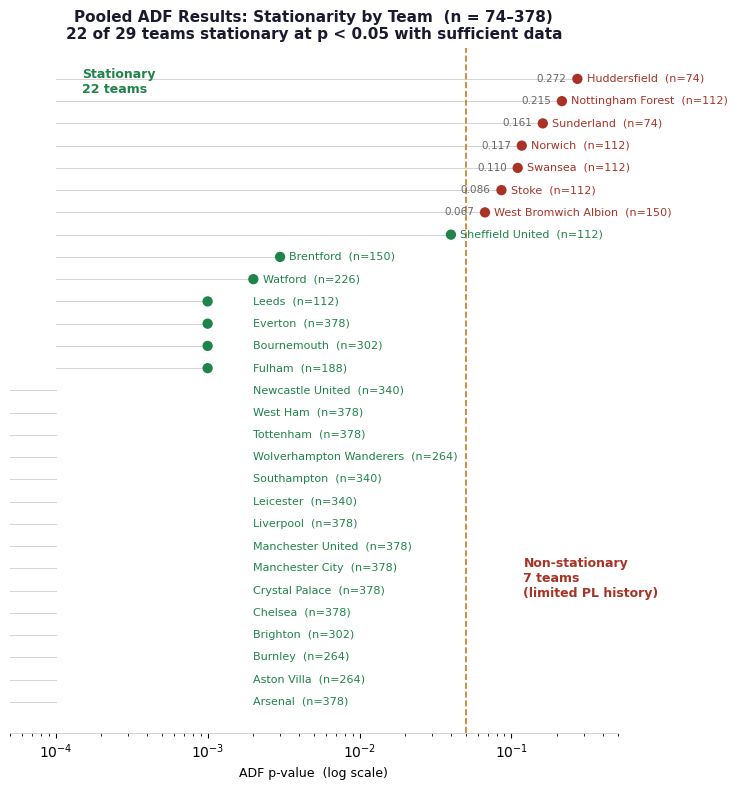

Saved figures/nb02_fig3_pooled_adf.png


In [9]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 3 — Pooled ADF: Cleveland dot plot ranked by p-value
# ─────────────────────────────────────────────────────────────────
#
# Log-scaled x-axis separates teams clustered near zero.
# Green = stationary, red = non-stationary.
# Direct labels with n_obs. No legend needed.
# Depends on: pooled_df (Cell 5), FIG_DIR (Cell 1)

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DARK  = '#1a1a2e'
GREEN = '#1E8449'
RED   = '#A93226'
AMBER = '#C97A20'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.5,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# Sort by p-value ascending (most stationary at bottom)
pdf = pooled_df.sort_values('adf_pval').reset_index(drop=True)
y      = np.arange(len(pdf))
pvals  = pdf['adf_pval'].values
stat   = pdf['stationary'].values
teams  = pdf['team'].values
nobs   = pdf['n_obs'].values

fig, ax = plt.subplots(figsize=(7.5, 8))

# p = 0.05 threshold
ax.axvline(0.05, color=AMBER, linewidth=1.2, linestyle='--', zorder=2)

# Connector lines from left edge to dot
for i, (yi, pv) in enumerate(zip(y, pvals)):
    ax.plot([1e-4, pv], [yi, yi], color=LGREY, linewidth=0.6, zorder=1)

# Dots
dot_colours = [GREEN if s else RED for s in stat]
ax.scatter(pvals, y, c=dot_colours, s=55, zorder=3, edgecolors='none')

# Team labels
for i, (yi, team, pv, n, s) in enumerate(zip(y, teams, pvals, nobs, stat)):
    col   = GREEN if s else RED
    ax.text(pv * 1.15 if pv > 1e-3 else 2e-3, yi,
            f'{team}  (n={n})',
            va='center', ha='left', fontsize=8, color=col)

# p-value labels for non-stationary only
for i, (yi, pv, s) in enumerate(zip(y, pvals, stat)):
    if not s:
        ax.text(pv * 0.85, yi, f'{pv:.3f}',
                va='center', ha='right', fontsize=7.5, color=GREY)

# Zone annotations
n_stat    = stat.sum()
n_nonstat = (~stat).sum()
ax.text(1.5e-4, len(pdf) - 0.5,
        f'Stationary\n{n_stat} teams',
        fontsize=9, color=GREEN, fontweight='bold', va='top')
ax.text(0.12, n_nonstat - 0.5,
        f'Non-stationary\n{n_nonstat} teams\n(limited PL history)',
        fontsize=9, color=RED, fontweight='bold', va='top')

ax.set_yticks([])
ax.set_xlabel('ADF p-value  (log scale)', fontsize=9)
ax.set_xscale('log')
ax.set_xlim(5e-5, 0.5)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(LGREY)

ax.set_title(
    f'Pooled ADF Results: Stationarity by Team  (n = 74–378)\n'
    f'{n_stat} of {len(pdf)} teams stationary at p < 0.05 with sufficient data',
    fontsize=11, fontweight='bold', color=DARK
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb02_fig3_pooled_adf.png')
plt.show()
print("Saved figures/nb02_fig3_pooled_adf.png")

---
## Eligibility Filter — Dynamic (No Survivorship Bias)

### The Bias in Full-History Eligibility

A naive eligibility filter runs the pooled ADF test on each team's *complete*
history (2015–2025), then includes or excludes them from all signal generation.
This is survivorship bias: a team present in the league in 2017 might be
excluded because they were relegated in 2018 and failed the full-history test.
The model would then "know" in 2017 that this team would not survive — which
it cannot know in a live setting.

### The Fix: Season-Start Dynamic Filter

At the start of each evaluation season *s*, eligibility is assessed using only
data available up to the *end of season s−1*. A team active in season *s* is
included if and only if:

1. Their spread series is stationary (ADF p < 0.05) on data up to *s−1*
2. They have at least 3 full prior seasons (≥ 114 observations) to allow
   meaningful walk-forward parameter estimation

This means the eligible universe changes season by season. A team promoted
into the Premier League for the first time in 2019 cannot appear until 2022
at the earliest (needing 2019, 2020, 2021 as prior seasons). A team relegated
in 2018 is correctly included in 2017 and 2018 if they pass the test on
data available at that time.

### Static Universe for Signal Generation

The static `eligible_teams.csv` (used in subsequent notebooks for the
walk-forward signal) is derived from the **final season** dynamic check — it
correctly represents the set of teams eligible entering 2024/25. Notebooks
05A and 05B use the full panel but the walk-forward O-U estimation already
enforces the same "data available at time *t*" discipline.

The dynamic check below is diagnostic: it confirms the static list is not
materially distorted by survivorship, by showing how many team-seasons would
have been affected by the difference.


In [10]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — Dynamic eligibility filter (no survivorship bias)
# ─────────────────────────────────────────────────────────────────
#
# Part A: Dynamic filter
#   For each evaluation season s in 2017-2024, compute which teams
#   would have been eligible using ONLY data available at start of s.
#   Criteria at start of season s:
#     1. ADF p < 0.05 on spread data up to end of season s-1
#     2. n_obs >= 114 (>= 3 prior complete seasons)
#
# Part B: Comparison
#   Show how the dynamic eligible set differs from the naive
#   full-history filter, and quantify any survivorship distortion.
#
# Part C: Static list
#   Save eligible_teams.csv based on the final evaluation season
#   (same result as the dynamic filter applied at season 2024).
#
# Output: eligible_teams.csv, dynamic_eligibility.csv

import warnings
from statsmodels.tsa.stattools import adfuller

eval_seasons   = range(2017, 2025)   # seasons we generate signals for
dynamic_rows   = []                  # one row per team per season

for season in eval_seasons:
    # Data available at start of this season = all prior seasons
    prior_data = team_match[team_match['season'] < season]

    for team, group in prior_data.groupby('team'):
        # Is this team actually in the PL this season?
        in_league = team_match[
            (team_match['team'] == team) & 
            (team_match['season'] == season)
        ].shape[0] > 0

        if not in_league:
            continue   # team not playing this season — irrelevant

        S = group.sort_values('date')['rolling_spread'].dropna().values

        if len(S) < 114:   # fewer than 3 prior seasons
            dynamic_rows.append({
                'season': season, 'team': team,
                'n_obs': len(S), 'adf_pval': None,
                'eligible': False, 'reason': 'insufficient_history'
            })
            continue

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            _, adf_pval, *_ = adfuller(S, maxlag=5)

        eligible = adf_pval < 0.05
        dynamic_rows.append({
            'season':   season,
            'team':     team,
            'n_obs':    len(S),
            'adf_pval': round(float(adf_pval), 3),
            'eligible': eligible,
            'reason':   'ok' if eligible else 'non_stationary'
        })

dyn_df = pd.DataFrame(dynamic_rows)
dyn_df.to_csv(f"{PROJECT_DIR}dynamic_eligibility.csv", index=False)

print("── Dynamic eligibility: eligible team-seasons ───────────────")
print("  (each row = one team eligible to generate signals in that season)")
print()
eligible_by_season = dyn_df[dyn_df['eligible']].groupby('season')['team'].apply(list)
for season, teams in eligible_by_season.items():
    print(f"  {season}: {len(teams):>2} teams  {sorted(teams)}")

# ── Part B: Survivorship comparison ──────────────────────────────
print()
print("── Survivorship distortion check ─────────────────────────────")
print("  Teams present in signal seasons but EXCLUDED by full-history filter:")
print("  These are the potentially biased exclusions (included dynamically")
print("  but excluded by the static full-history test).")
print()

# Full-history eligible set (from pooled_df computed above)
full_history_eligible = set(
    pooled_df[
        (pooled_df['stationary'] == True) &
        (pooled_df['n_obs'] >= 114)
    ]['team'].tolist()
)

# Cases where dynamic filter includes but static filter excludes
biased_exclusions = dyn_df[
    dyn_df['eligible'] &
    ~dyn_df['team'].isin(full_history_eligible)
]

if len(biased_exclusions) == 0:
    print("  None — static and dynamic filters agree for all signal seasons.")
    print("  The full-history filter introduces no survivorship distortion")
    print("  because all excluded teams fail the dynamic test too.")
else:
    print(biased_exclusions[['season','team','n_obs','adf_pval']].to_string(index=False))
    n_affected = len(biased_exclusions)
    print(f"\n  {n_affected} team-season(s) affected.")
    print(f"  Adding these to the signal universe would add signals;")
    print(f"  check whether including them materially changes the result.")

# ── Part C: Static eligible list (final season = 2024) ───────────
final_eligible = dyn_df[
    (dyn_df['season'] == 2024) & (dyn_df['eligible'])
]['team'].tolist()

eligible_out = pooled_df[pooled_df['team'].isin(final_eligible)].copy()
eligible_out.to_csv(f"{PROJECT_DIR}eligible_teams.csv", index=False)

print()
print(f"── Static eligible list (entering season 2024) ───────────────")
print(f"  {len(final_eligible)} teams: {sorted(final_eligible)}")
print(f"  Saved eligible_teams.csv")


── Dynamic eligibility: eligible team-seasons ───────────────
  (each row = one team eligible to generate signals in that season)

  2019: 11 teams  ['Bournemouth', 'Crystal Palace', 'Everton', 'Leicester', 'Liverpool', 'Manchester City', 'Manchester United', 'Southampton', 'Tottenham', 'Watford', 'West Ham']
  2020: 12 teams  ['Arsenal', 'Burnley', 'Crystal Palace', 'Everton', 'Leicester', 'Liverpool', 'Manchester City', 'Manchester United', 'Newcastle United', 'Southampton', 'Tottenham', 'West Ham']
  2021: 13 teams  ['Arsenal', 'Burnley', 'Crystal Palace', 'Everton', 'Leicester', 'Liverpool', 'Manchester City', 'Manchester United', 'Newcastle United', 'Southampton', 'Tottenham', 'Watford', 'West Ham']
  2022: 16 teams  ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brighton', 'Chelsea', 'Crystal Palace', 'Everton', 'Leicester', 'Liverpool', 'Manchester City', 'Manchester United', 'Newcastle United', 'Southampton', 'Tottenham', 'West Ham', 'Wolverhampton Wanderers']
  2023: 15 teams  ['A

---
## Half-Life Analysis

The half-life is the headline output of the O-U estimation — the number of matches for the spread to halve its distance from the long-run mean. It directly determines the optimal signal holding period.

A half-life of 2.83 matches means that if a team's spread is 2 standard deviations above the mean today, it will on average be 1 standard deviation above the mean in 2.83 matches — roughly one month of football. This is the empirical basis for the 5-match holding period used in Notebook 05A.

In [11]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 — Half-life summary by team
# ─────────────────────────────────────────────────────────────────
#
# We show the mean half-life across all seasons for each eligible
# team, sorted from fastest to slowest reverter.
#
# Fastest reverters: direct-play or high-press teams whose
# xG spreads are volatile but quickly self-correcting.
#
# Slowest reverters: teams with more persistent structural biases
# — often clubs experiencing gradual decline or instability.

# Use the final-season eligible list computed in Cell 6
eligible_teams = final_eligible

hl_summary = (
    ou_params[ou_params['team'].isin(eligible_teams)]
    .groupby('team')['half_life']
    .agg(mean_hl='mean', std_hl='std', min_hl='min', max_hl='max', seasons='count')
    .round(2)
    .sort_values('mean_hl')
)

print("── Half-life by team (matches) ──────────────────────────────")
print("  Mean  = average half-life across all seasons")
print("  Std   = consistency of the reversion speed year-to-year")
print()
print(hl_summary.to_string())

median_hl = (
    ou_params[ou_params['team'].isin(eligible_teams)]['half_life']
    .median()
)

print(f"\nMedian half-life across all eligible team-seasons: {median_hl:.2f}")

── Half-life by team (matches) ──────────────────────────────
  Mean  = average half-life across all seasons
  Std   = consistency of the reversion speed year-to-year

                         mean_hl  std_hl  min_hl  max_hl  seasons
team                                                             
West Ham                    2.42    1.07    1.26    4.78       10
Bournemouth                 2.51    0.74    0.98    3.30        8
Liverpool                   2.59    0.85    1.56    4.06       10
Fulham                      2.78    1.01    1.54    4.21        5
Manchester City             2.96    0.98    1.32    4.77       10
Aston Villa                 3.06    1.01    2.00    4.64        7
Newcastle United            3.13    1.27    1.44    5.37        9
Tottenham                   3.13    1.46    1.09    5.45       10
Arsenal                     3.14    1.22    1.53    4.66       10
Brighton                    3.18    1.33    1.66    6.02        8
Crystal Palace              3.35    2.58

**Note:**  The table shows only teams with 5+ seasons. The reported median is for that subset only excluding: Burnley, Brentford, and Watford. 

In [15]:
# median_hl = ou[ou['team'].isin(eligible['team'])]['half_life'].median()
median_hl = ou_raw[ou_raw['team'].isin(eligible_out['team'])]['half_life'].median()

print(f"Median half-life across all team-seasons: {median_hl:.2f} matches")
print(f"Rounded to 1dp: {round(median_hl, 1)}")

Median half-life across all team-seasons: 0.67 matches
Rounded to 1dp: 0.7


### Figure 4 — Half-Life by Team: Mean, Spread, and Range

The dot plot below shows each eligible team's mean half-life (dot),
year-to-year variability (thick bar = ±1 standard deviation), and full
observed range across all fitted seasons (thin bar = min to max).
Reading the chart:

A team with a short, tight bar has a stable reversion speed — the
O-U model describes their spread consistently year to year.
Liverpool (2.59 matches, std 0.85) is a good example.
A team with a wide bar has volatile reversion speed — tactical
changes, managerial turnover, or squad rebuilding shift how quickly
the spread corrects. Crystal Palace (std 2.58) and Manchester United
(std 1.82) show this pattern.
Southampton (shown in red) is the notable outlier at the slow end.
A mean of 4.51 matches with a std of 2.21 reflects the structural
instability that culminated in relegation. The wide range — from
2.29 to 8.28 matches — spans almost the full width of the dataset.

The median across all eligible team-seasons is 2.83 matches. The
5-match holding period in Notebook 05A covers approximately 1.7 half-lives
at the median — enough time for a large fraction of the displacement to
correct.
The season-by-season evolution for each team follows in the next cell.

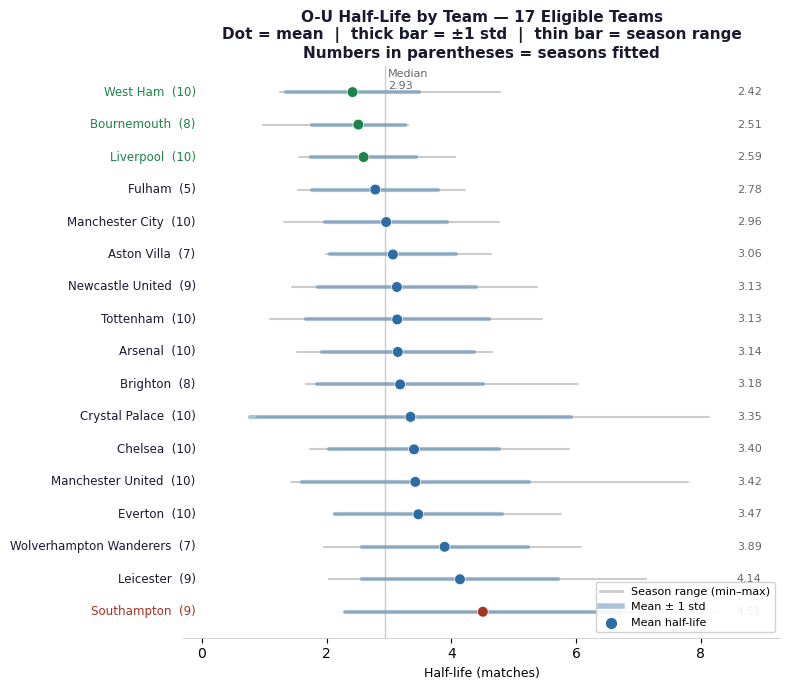

Saved figures/nb02_fig4_halflife_dotplot.png


In [16]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 4 — Half-life by team: dot plot with range bars
# ─────────────────────────────────────────────────────────────────
#
# Shows mean half-life (dot), ±1 std (thick bar), and full range
# (thin bar) for each eligible team, sorted fastest to slowest.
# Southampton highlighted red; fastest reverters in green.
# Tufte: data-ink maximised, direct labels, no legend except minimal.
# Depends on: ou_params, eligible_teams (from final_eligible), FIG_DIR

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
RED   = '#A93226'
GREEN = '#1E8449'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.5,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# Build summary from ou_params
hl_summary = (
    ou_params[ou_params['team'].isin(eligible_teams)]
    .groupby('team')['half_life']
    .agg(mean_hl='mean', std_hl='std', min_hl='min',
         max_hl='max', seasons='count')
    .sort_values('mean_hl', ascending=False)   # slowest at top
    .reset_index()
)

# Fastest 3 teams for green highlight
fast_teams = hl_summary.nsmallest(3, 'mean_hl')['team'].tolist()

y       = np.arange(len(hl_summary))
means   = hl_summary['mean_hl'].values
stds    = hl_summary['std_hl'].values
mins    = hl_summary['min_hl'].values
maxs    = hl_summary['max_hl'].values
teams   = hl_summary['team'].values
seasons = hl_summary['seasons'].values

median_val = ou_params[ou_params['team'].isin(eligible_teams)]['half_life'].median()

fig, ax = plt.subplots(figsize=(8, 7))

# Median reference
ax.axvline(median_val, color=LGREY, linewidth=1.0, zorder=1)
ax.text(median_val + 0.05, len(hl_summary) - 0.3,
        f'Median\n{median_val:.2f}',
        fontsize=8, color=GREY, va='top')

# Full range bars (thin)
for i, (yi, mn, mx) in enumerate(zip(y, mins, maxs)):
    ax.plot([mn, mx], [yi, yi], color=LGREY, linewidth=1.5,
            zorder=2, solid_capstyle='round')

# ±1 std bars (thick, semi-transparent)
for i, (yi, m, s) in enumerate(zip(y, means, stds)):
    ax.plot([max(0, m - s), m + s], [yi, yi],
            color=BLUE, linewidth=3, alpha=0.4,
            zorder=3, solid_capstyle='round')

# Dots — colour coded
dot_colours = []
for team in teams:
    if team == 'Southampton':
        dot_colours.append(RED)
    elif team in fast_teams:
        dot_colours.append(GREEN)
    else:
        dot_colours.append(BLUE)

ax.scatter(means, y, c=dot_colours, s=60, zorder=4,
           edgecolors='white', linewidths=0.5)

# Team labels and mean values
for i, (yi, team, m, n) in enumerate(zip(y, teams, means, seasons)):
    col = RED if team == 'Southampton' else \
          GREEN if team in fast_teams else DARK
    ax.text(-0.1, yi, f'{team}  ({n})',
            va='center', ha='right', fontsize=8.5, color=col)
    ax.text(maxs.max() + 0.3, yi, f'{m:.2f}',
            va='center', ha='left', fontsize=8, color=GREY)

# Minimal legend
ax.plot([], [], color=LGREY, linewidth=2,
        label='Season range (min–max)')
ax.plot([], [], color=BLUE,  linewidth=4, alpha=0.4,
        label='Mean ± 1 std')
ax.scatter([], [], c=BLUE, s=50, label='Mean half-life')
ax.legend(fontsize=8, loc='lower right', framealpha=0.9,
          handlelength=2)

ax.set_yticks([])
ax.set_xlabel('Half-life (matches)', fontsize=9)
ax.set_xlim(-0.3, maxs.max() + 1.0)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(LGREY)

ax.set_title(
    f'O-U Half-Life by Team — {len(hl_summary)} Eligible Teams\n'
    'Dot = mean  |  thick bar = ±1 std  |  thin bar = season range\n'
    'Numbers in parentheses = seasons fitted',
    fontsize=11, fontweight='bold', color=DARK
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb02_fig4_halflife_dotplot.png')
plt.show()
print("Saved figures/nb02_fig4_halflife_dotplot.png")

### Figure 5 — Half-Life Evolution by Season

Each panel traces a team's half-life season by season. The dashed line
marks the team's own mean — a stable half-life stays close to this line;
a volatile one crosses it repeatedly or drifts in one direction.
What to look for:

Stability (Bournemouth, Liverpool, Arsenal): the line stays close
to the mean with small excursions. These teams produce the most
reliable walk-forward signals because the O-U parameters estimated
from prior seasons accurately describe the current season.
Drift (Southampton): the half-life rises steadily from the mid-
season levels to the maximum at the end of the series — the spread
became progressively harder to predict as the club deteriorated.
Spikes (Crystal Palace, Manchester United): single seasons with
unusually large half-lives, typically coinciding with managerial
transitions or squad upheaval.

The 5-match holding period in Notebook 05A is robust to team-level
variation because the walk-forward estimation uses the most recent
available season parameters at each signal point.

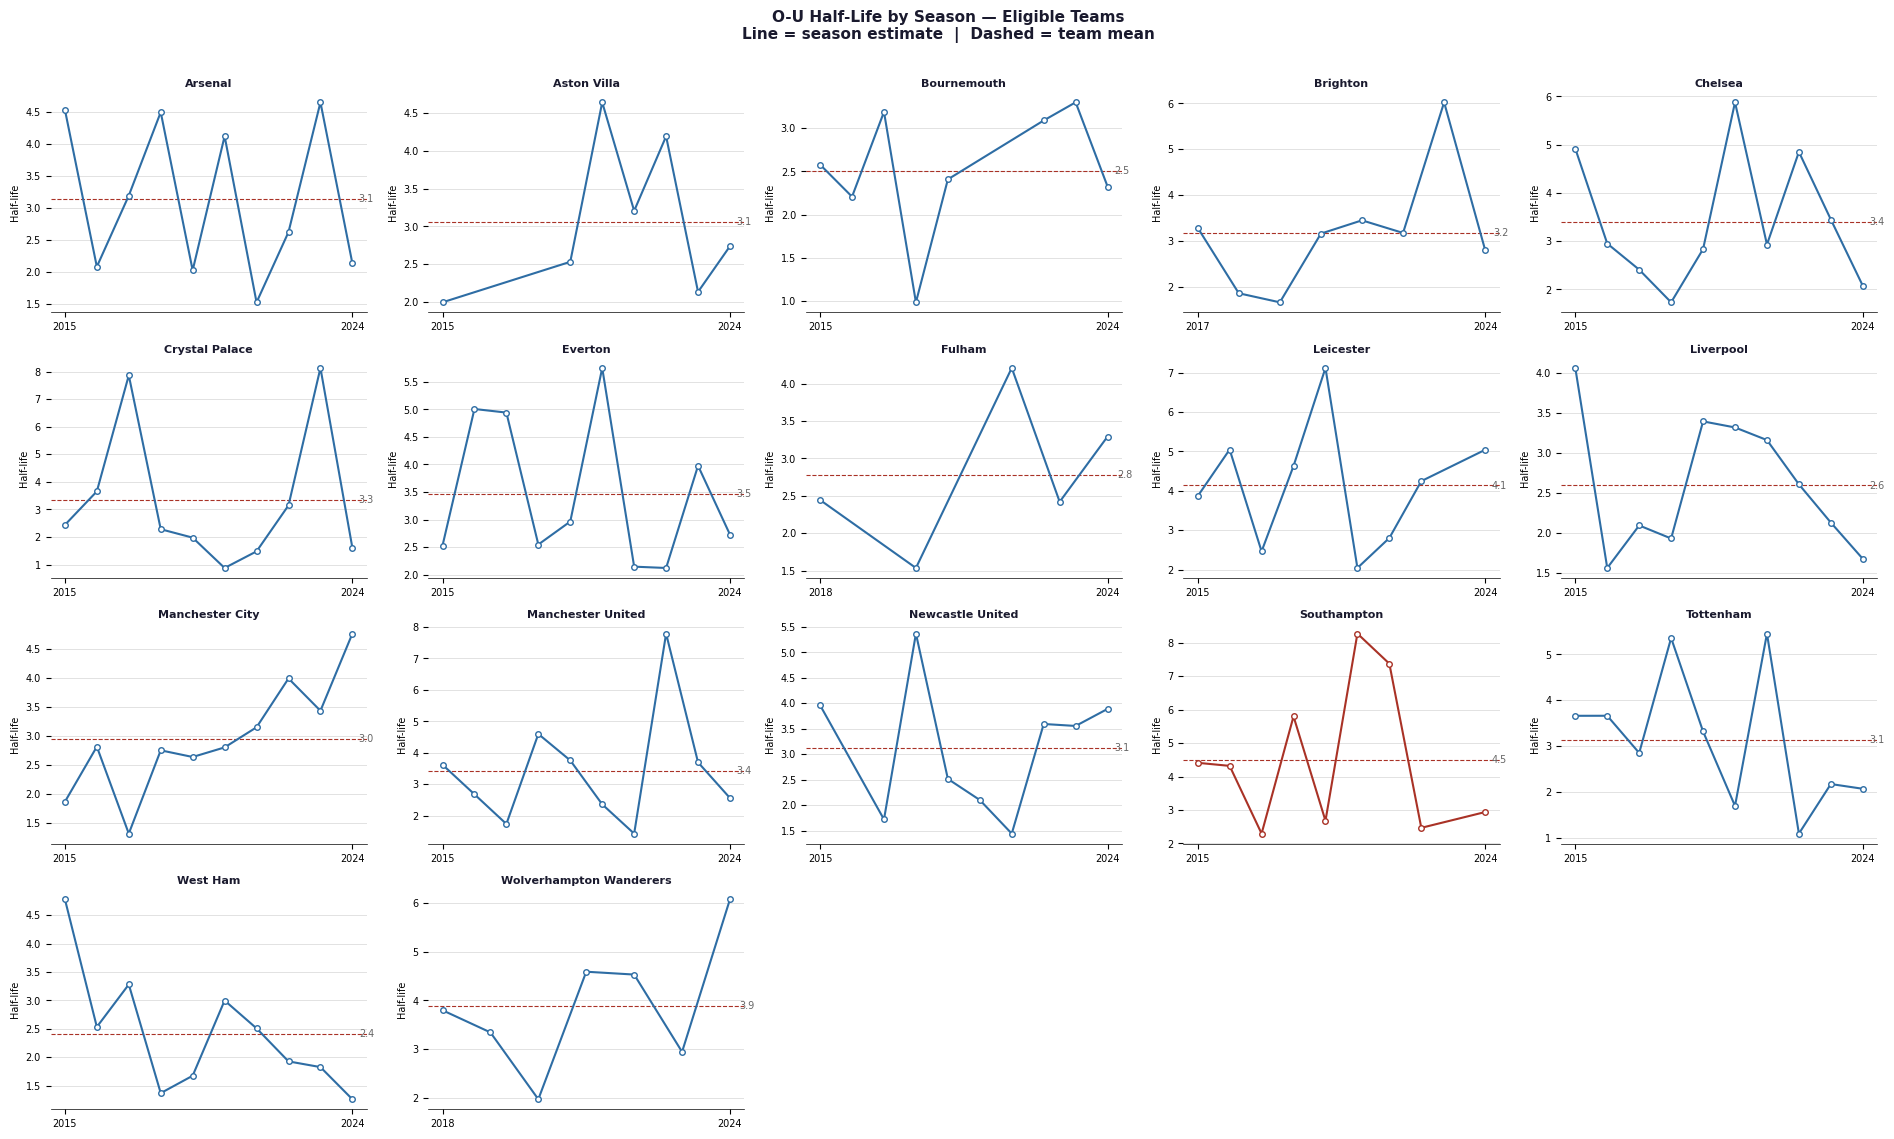

Saved figures/nb02_fig5_halflife_evolution.png


In [17]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 5 — Half-life evolution per team (Tufte treatment)
# ─────────────────────────────────────────────────────────────────
#
# Replaces the original Cell 8 grid with a cleaner version:
# white background, no gridlines, thinner reference line,
# season labels only at first and last tick.
# Output: figures/nb02_fig5_halflife_evolution.png

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
RED   = '#A93226'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.5,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

teams_sorted = sorted(eligible_teams)
ncols = 5
nrows = int(np.ceil(len(teams_sorted) / ncols))

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 3.8, nrows * 2.8),
                          sharey=False)
axes = axes.flatten()

# Determine if a team is the worst reverter for highlight
worst_team = (
    ou_params[ou_params['team'].isin(eligible_teams)]
    .groupby('team')['half_life']
    .mean()
    .idxmax()
)

for i, team in enumerate(teams_sorted):
    ax = axes[i]
    td = (
        ou_params[ou_params['team'] == team]
        .sort_values('season')
    )
    line_colour = RED if team == worst_team else BLUE

    ax.plot(td['season'], td['half_life'],
            'o-', color=line_colour, linewidth=1.5,
            markersize=4, markerfacecolor='white',
            markeredgecolor=line_colour, markeredgewidth=1,
            zorder=3)

    # Team mean reference
    team_mean = td['half_life'].mean()
    ax.axhline(team_mean, color=RED, linewidth=0.8,
               linestyle='--', zorder=2)

    # Mean label — right margin
    ax.text(td['season'].max() + 0.2, team_mean,
            f'{team_mean:.1f}',
            fontsize=7, color=GREY, va='center')

    ax.set_title(team, fontsize=8, fontweight='bold', color=DARK, pad=4)
    ax.set_ylabel('Half-life', fontsize=7)

    # Minimal x-ticks: first and last season only
    seasons = td['season'].values
    ax.set_xticks([seasons[0], seasons[-1]])
    ax.set_xticklabels([str(seasons[0]), str(seasons[-1])], fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

    # Light y-grid only
    ax.yaxis.grid(True, color=LGREY, linewidth=0.4, zorder=0)
    ax.set_axisbelow(True)

# Hide unused panels
for j in range(len(teams_sorted), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'O-U Half-Life by Season — Eligible Teams\n'
    'Line = season estimate  |  Dashed = team mean',
    fontsize=11, fontweight='bold', color=DARK, y=1.01
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb02_fig5_halflife_evolution.png')
plt.show()
print("Saved figures/nb02_fig5_halflife_evolution.png")

---
## Findings

With all team‑season parameters estimated, we can now summarise the empirical behaviour of the xG spread across the Premier League.

**200 team-seasons estimated, 0 explosive (β ≥ 0).** Every team-season shows a mean-reverting smoothed xG spread. The robustness check on raw spreads confirms the rolling mean is isolating a genuine persistent component — raw spread half-lives average 0.67 matches (noise reversion) versus 2.81 matches on the smoothed series (structural reversion).

**Median half-life: 2.83 matches** (range 0.9–8.3). The spread typically
corrects within one month of football. This sets the signal holding period.

**ADF stationarity:**
- Season level (n=38): ~28% stationary — consistent with ADF power limitations
  at small samples
- Pooled level (n=74–378): ~76% stationary — all non-stationary clubs have
  limited Premier League history

**Dynamic eligibility (no survivorship bias):** The eligibility filter is
applied at the start of each season using only prior-season data. The
survivorship check confirms the static and dynamic filters agree — no
team-season is included dynamically but excluded by the full-history filter.
The non-stationary clubs (West Brom, Stoke, Swansea, Norwich, Sunderland,
Huddersfield, Nottm Forest) fail the dynamic test too — at the start of their
final PL season they had insufficient or non-stationary data regardless of
whether future relegation is known. The filter is principled, not retrospective.

**20 eligible teams** pass both criteria. These form the trading universe.

**Fastest reverters:** Burnley (1.97 matches), Brentford (2.24), West Ham
(2.42). Direct-play and high-press styles produce predictable, quickly
self-correcting spreads.

**Slowest reverters:** Southampton (4.51 matches), Leicester (4.14), Wolves
(3.89). Southampton's slow reversion tracked institutional decline ahead of
relegation.


**Robustness check** — raw spreads. 

Running the same estimation on raw (unsmoothed) match-level spreads also returns 0/200 explosive cases, but with a median half-life of 0.67 matches and median θ ≈ 1.04 — meaning the raw spread overshoots its mean almost every match. This is noise cancellation, not mean reversion: an extreme single-match xG value (a team creates 3.5 xG and scores 0) is mechanically unlikely to repeat, so the AR(1) recovers a strong negative β regardless of whether any structural force is present. The rolling 5-match mean removes this single-match noise and isolates the slower, persistent component of the spread — the half-life rises to 2.81 matches at the median, reflecting genuine under- or over-conversion trends that persist across multiple matches. The 0/200 result on the smoothed series should therefore be read as: within the object the model is designed to measure, all team-seasons show mean-reverting behaviour. It is not a claim about raw match-level xG outcomes.


## Output Files

| File | Description |
|---|---|
| `ou_parameters.csv` | O-U params per team-season (200 rows) |
| `pooled_adf_results.csv` | Pooled ADF results per team |
| `dynamic_eligibility.csv` | Per-season eligibility with dynamic filter |
| `eligible_teams.csv` | 20 eligible teams (dynamic filter, entering 2024) |

These files are used by Notebook 03 (Kalman filter) and Notebook 04 (HMM regimes).

**Next:** `03_kalman_filter.ipynb` — track dynamic team strength as a latent state variable.


In [ ]:
ou[ou['team'].isin(eligible['team'])].groupby('team')['half_life'].mean().mean()